In [1]:
import sys
sys.path.append("../src")
from connect_db import get_engine

Connected successfully!


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import squarify

In [3]:
engine = get_engine()

In [4]:
query =  """
    SELECT *
    FROM vw_sales
    
    """


In [5]:
sales_df = pd.read_sql(query,engine)
sales_df.head()

,order_id,purchase_date,month,year,payment_value
0,a9810da82917af2d9aefd1278f1dcfa0,2018-06-26 11:01:38,6.0,2018.0,24.39
1,ba78997921bbcdc1373bb41e913ab953,2017-12-06 12:04:06,12.0,2017.0,107.78
2,42fdf880ba16b47b59251dd489d4441a,2018-05-21 13:59:17,5.0,2018.0,128.45
3,298fcdf1f73eb413e4d26d01b25bc1cd,2018-05-07 13:20:41,5.0,2018.0,96.12
4,1f78449c87a54faf9e96e88ba1491fa9,2018-07-22 14:07:35,7.0,2018.0,341.09


In [6]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       103886 non-null  object        
 1   purchase_date  103886 non-null  datetime64[ns]
 2   month          103886 non-null  float64       
 3   year           103886 non-null  float64       
 4   payment_value  103886 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 4.0+ MB


In [7]:
sales_df['month'] = sales_df['month'].astype('int')
sales_df['year'] = sales_df['year'].astype('int')

In [8]:
sales_df.head()

,order_id,purchase_date,month,year,payment_value
0,a9810da82917af2d9aefd1278f1dcfa0,2018-06-26 11:01:38,6,2018,24.39
1,ba78997921bbcdc1373bb41e913ab953,2017-12-06 12:04:06,12,2017,107.78
2,42fdf880ba16b47b59251dd489d4441a,2018-05-21 13:59:17,5,2018,128.45
3,298fcdf1f73eb413e4d26d01b25bc1cd,2018-05-07 13:20:41,5,2018,96.12
4,1f78449c87a54faf9e96e88ba1491fa9,2018-07-22 14:07:35,7,2018,341.09


# Revenue Analysis 

In [9]:
total_revenue = sales_df['payment_value'].sum()
total_order = sales_df['order_id'].nunique()
print(f'Total_Revenue : {total_revenue:,.2f}')
print(f'Total_Orders : {total_order:,}')

Total_Revenue : 16,008,872.12
Total_Orders : 99,440


In [10]:
monthly_revenue = (sales_df.groupby('month')['payment_value'].sum().reset_index().sort_values('payment_value', ascending=False))
monthly_revenue

,month,payment_value
4,5,1746900.97
7,8,1696821.64
6,7,1658923.67
2,3,1609515.72
3,4,1578573.51
5,6,1535156.88
1,2,1284371.35
0,1,1253492.22
10,11,1194882.80
11,12,878421.10


In [11]:
year_revenue = (sales_df.groupby('year')['payment_value'].sum().reset_index().sort_values('payment_value', ascending=False))
year_revenue

,year,payment_value
2,2018,8699763.05
1,2017,7249746.73
0,2016,59362.34


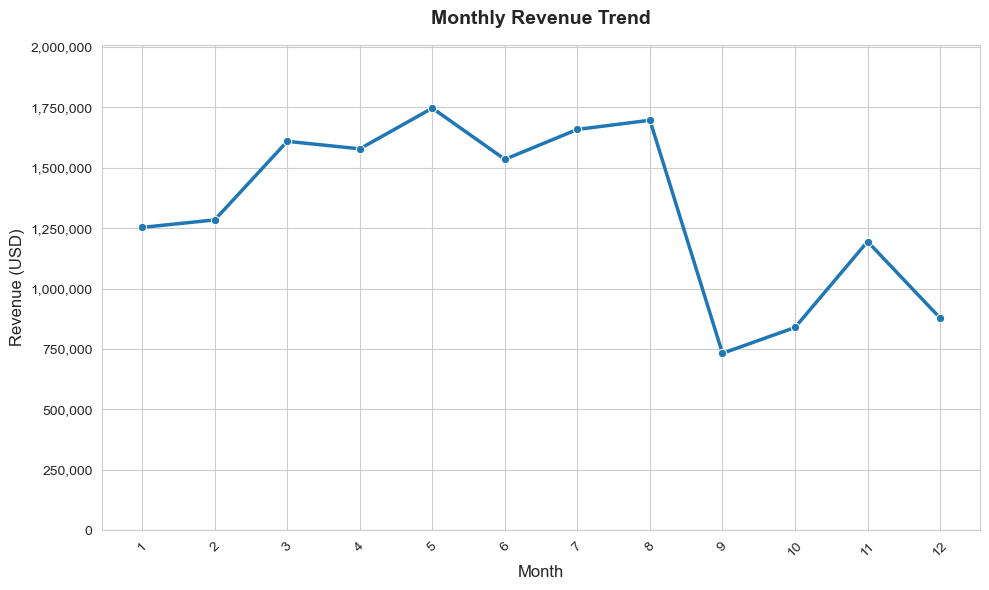

In [51]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="payment_value",
    marker='o',
    linewidth=2.5,
    color='#1f77b4'
)
plt.ticklabel_format(style='plain', axis='y')
ax = plt.gca()
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.title("Monthly Revenue Trend", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (USD)", fontsize=12)
plt.xticks(ticks=monthly_revenue["month"], rotation=45)
plt.ylim(0, monthly_revenue['payment_value'].max() * 1.15)
plt.tight_layout()
plt.savefig('../report/monthly_revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Xu hướng Doanh thu Hàng tháng (Monthly Revenue Trend)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu tham chiếu:** Bảng số liệu chi tiết sắp xếp theo giá trị từ lớn đến bé  và Biểu đồ đường xu hướng thời gian .
* **Loại biểu đồ:** Biểu đồ đường (Line chart) có các điểm đánh dấu giá trị (markers).
* **Tiêu đề:** Monthly Revenue Trend (Xu hướng doanh thu hàng tháng).
* **Trục tung (Y-axis):** Revenue (USD) - Doanh thu tính theo đơn vị đô la Mỹ (dao động từ mốc 0 đến 2,000,000 USD).
* **Trục hoành (X-axis):** Month - Các tháng trong năm (từ tháng 1 đến tháng 12).

---

## 2. Số liệu Chi tiết từ Dữ liệu (Sắp xếp theo thứ tự thời gian)

Kết hợp từ hai tệp `image_4ce143.png` và `image_4cde81.png`, giá trị doanh thu chính xác của các tháng được ghi nhận như sau:

* **Tháng 1:** 1,253,492.22 USD
* **Tháng 2:** 1,284,371.35 USD
* **Tháng 3:** 1,609,515.72 USD
* **Tháng 4:** 1,578,573.51 USD
* **Tháng 5:** 1,746,900.97 USD *(Đỉnh điểm - Peak)*
* **Tháng 6:** 1,535,156.88 USD
* **Tháng 7:** 1,658,923.67 USD
* **Tháng 8:** 1,696,821.64 USD
* **Tháng 9:** 732,454.23 USD *(Chạm đáy - Trough)*
* **Tháng 10:** 839,358.03 USD
* **Tháng 11:** 1,194,882.80 USD
* **Tháng 12:** 878,421.10 USD

---

## 3. Nhận xét và Đánh giá (Insights)

* **Giai đoạn hiệu suất cao duy trì ổn định (Tháng 3 - Tháng 8):**
  * Doanh thu của doanh nghiệp tăng trưởng mạnh mẽ và giữ vững phong độ ổn định trên mức 1.5 triệu USD/tháng trong suốt 6 tháng liên tiếp (từ tháng 3 đến tháng 8).
  * **Đỉnh điểm doanh thu:** Rơi vào **Tháng 5** với giá trị đạt cao nhất toàn hệ thống là **1,746,900.97 USD**. Tháng 8 theo sát phía sau và là tháng có doanh thu cao thứ hai với **1,696,821.64 USD**.

* **Cú sụt giảm nghiêm trọng vào Tháng 9:**
  * Điểm biến động mạnh nhất của biểu đồ xu hướng là sự suy giảm đột ngột và sâu sắc vào **Tháng 9**, khi doanh thu lao dốc thẳng đứng từ mức gần 1.7 triệu USD (Tháng 8) xuống chỉ còn **732,454.23 USD** (giảm hơn một nửa). Đây cũng là tháng ghi nhận doanh thu thấp nhất trong năm.

* **Sự phục hồi ngắn hạn và kết thúc năm:**
  * Sau khi chạm đáy vào tháng 9, doanh thu có xu hướng hồi phục dần trong tháng 10 và bứt phá trở lại mức trên 1.1 triệu USD vào tháng 11. 
  * Tuy nhiên, đà hồi phục này không giữ được lâu khi tháng 12 tiếp tục chứng kiến một sự sụt giảm nhẹ khác xuống còn **878,421.10 USD**.

In [13]:
monthly_order = (sales_df.groupby('month')['order_id'].nunique().reset_index().sort_values('order_id', ascending= False))
monthly_order

,month,order_id
7,8,10843
4,5,10573
6,7,10318
2,3,9893
5,6,9412
3,4,9343
1,2,8508
0,1,8069
10,11,7544
11,12,5674


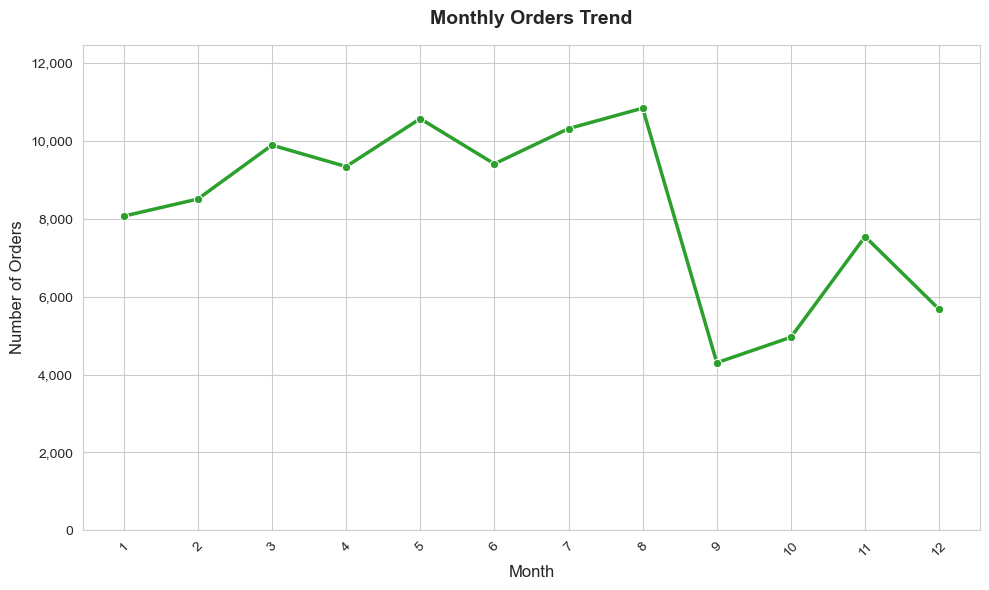

In [52]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=monthly_order,
    x="month",
    y="order_id",
    marker='o',
    linewidth=2.5,
    color='#2ca02c' 
)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.xticks(ticks=monthly_order["month"], rotation=45)
plt.title("Monthly Orders Trend", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.ylim(0, monthly_order['order_id'].max() * 1.15)
plt.tight_layout()
plt.savefig('../report/monthly_orders_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Xu hướng Số lượng Đơn hàng Hàng tháng (Monthly Orders Trend)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu tham chiếu:** Bảng số liệu chi tiết số lượng đơn hàng sắp xếp theo giá trị giảm dần  và Biểu đồ đường xu hướng .
* **Loại biểu đồ:** Biểu đồ đường (Line chart) có các điểm đánh dấu giá trị (markers).
* **Tiêu đề:** Monthly Orders Trend (Xu hướng số lượng đơn hàng hàng tháng).
* **Trục tung (Y-axis):** Number of Orders - Số lượng đơn hàng (dao động từ mốc 0 đến 12,000 đơn).
* **Trục hoành (X-axis):** Month - Các tháng trong năm (từ tháng 1 đến tháng 12).

---

## 2. Số liệu Chi tiết từ Dữ liệu (Sắp xếp theo thứ tự thời gian)

Số lượng đơn hàng chính xác của từng tháng được ghi nhận như sau:

* **Tháng 1:** 8,069 đơn hàng
* **Tháng 2:** 8,508 đơn hàng
* **Tháng 3:** 9,893 đơn hàng
* **Tháng 4:** 9,343 đơn hàng
* **Tháng 5:** 10,573 đơn hàng
* **Tháng 6:** 9,412 đơn hàng
* **Tháng 7:** 10,318 đơn hàng
* **Tháng 8:** 10,843 đơn hàng *(Đỉnh điểm - Peak)*
* **Tháng 9:** 4,304 đơn hàng *(Chạm đáy - Trough)*
* **Tháng 10:** 4,959 đơn hàng
* **Tháng 11:** 7,544 đơn hàng
* **Tháng 12:** 5,674 đơn hàng

---

## 3. Nhận xét và Đánh giá (Insights)

* **Giai đoạn đạt hiệu suất cao và ổn định (Tháng 3 - Tháng 8):**
  * Số lượng đơn hàng duy trì ở mức cao và tương đối ổn định (đều đặn trên 9,000 đơn/tháng) trong suốt giai đoạn từ tháng 3 đến tháng 8.
  * **Đỉnh điểm số lượng đơn hàng:** Xu hướng tăng trưởng đạt mốc cao nhất vào **Tháng 8** với **10,843 đơn hàng**. Tháng 5 bám sát ngay sau với vị trí thứ hai đạt **10,573 đơn hàng**.

* **Cú lao dốc đột ngột vào Tháng 9:**
  * Biến động mạnh nhất trên biểu đồ xảy ra vào **Tháng 9**, khi số lượng đơn hàng sụt giảm nghiêm trọng từ mốc đỉnh hơn 10.8 nghìn đơn xuống chỉ còn **4,304 đơn hàng** (giảm khoảng 60%). Đây cũng là thời điểm lượng đơn hàng chạm mức thấp nhất trong toàn bộ năm.

* **Sự hồi phục cuối năm và biến động Tháng 12:**
  * Sau khi chạm đáy, lượng đơn hàng có tín hiệu phục hồi dần trong tháng 10 và bật tăng mạnh mẽ trở lại vào tháng 11 với **7,544 đơn hàng**.
  * Tuy nhiên, đà phục hồi này bị chững lại khi tháng 12 chứng kiến một đợt sụt giảm khác, đưa số lượng đơn hàng về mức **5,674 đơn**.

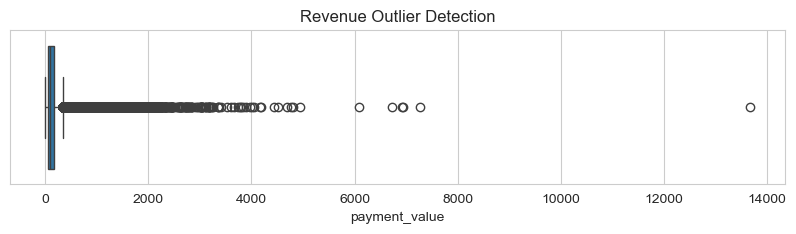

In [15]:
plt.figure(figsize=(10,2))
sns.boxplot( x=sales_df["payment_value"])
plt.title( "Revenue Outlier Detection")
plt.savefig('../report/revenue_outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
Q1 = sales_df["payment_value"].quantile(0.25)
Q3 = sales_df["payment_value"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = (Q1 - 1.5 * IQR)
upper_bound = (Q3 + 1.5 * IQR)
outliers = sales_df[(sales_df["payment_value"] < lower_bound )| ( sales_df["payment_value"] > upper_bound)]

In [17]:
print(f"Number of outliers: {len(outliers):,}")
print(f"Outlier Percentage: {len(outliers)/len(sales_df)*100:.2f}%")

Number of outliers: 7,981
Outlier Percentage: 7.68%


# Customer Analysis 

In [18]:
customer_df = pd.read_sql(
    "SELECT * FROM vw_customer_analysis",
    engine
)

In [19]:
customer_df.head()

,customer_unique_id,customer_state,total_orders,total_spending
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,1,27.19
2,0000f46a3911fa3c0805444483337064,SC,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,PA,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,SP,1,196.89


In [20]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96135 entries, 0 to 96134
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  96135 non-null  object 
 1   customer_state      96135 non-null  object 
 2   total_orders        96135 non-null  int64  
 3   total_spending      96135 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.9+ MB


In [21]:
customer_df.shape

(96135, 4)

In [22]:
total_customers = customer_df["customer_unique_id"].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 96,095


In [23]:
customer_state_dist = (customer_df
    .groupby("customer_state")
    .size()
    .reset_index(name="customer_count")
    .sort_values("customer_count",ascending=False)
)
customer_state_dist.head()

,customer_state,customer_count
25,SP,40301
18,RJ,12384
10,MG,11259
22,RS,5277
17,PR,4882


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20632\3415257577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


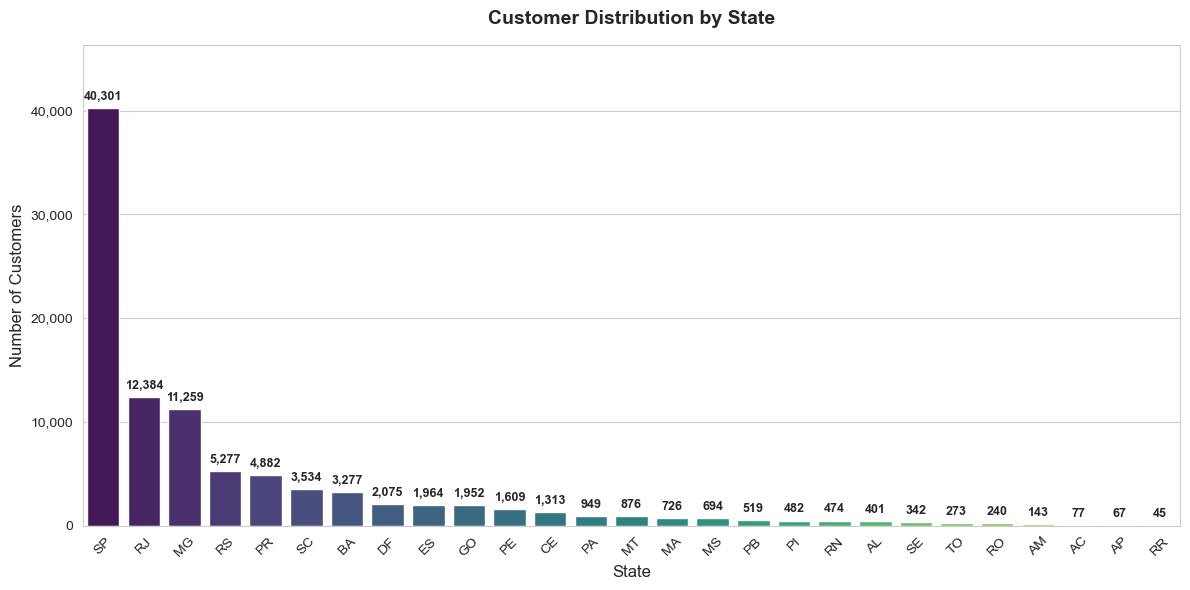

In [24]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=customer_state_dist,
    x="customer_state",
    y="customer_count",
    palette="viridis"
)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=9)
plt.title("Customer Distribution by State", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, customer_state_dist['customer_count'].max() * 1.15)
plt.tight_layout()
plt.savefig('../report/customer_distribution_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Phân bổ Khách hàng theo Bang (Customer Distribution by State)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã xử lý dữ liệu Pandas sử dụng hàm `.groupby()` kết hợp `.size()` trên biến `customer_df` và biểu đồ cột tần suất tương ứng.
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) hiển thị nhãn giá trị chính xác trên đầu mỗi cột.
* **Tiêu đề:** Customer Distribution by State (Phân bổ khách hàng theo Bang).
* **Trục tung (Y-axis):** Number of Customers - Số lượng khách hàng (dao động từ mốc 0 đến hơn 40,000).
* **Trục hoành (X-axis):** State - Viết tắt tên các bang (ví dụ dựa trên tập dữ liệu này: SP là São Paulo, RJ là Rio de Janeiro, MG là Minas Gerais,... thuộc thị trường Brazil).

---

## 2. Số liệu Chi tiết của Top 5 Bang Dẫn đầu
Dựa trên bảng số liệu từ mã nguồn và biểu đồ, 5 bang có lượng khách hàng lớn nhất được ghi nhận chính xác là:
1. **SP (São Paulo):** 40,301 khách hàng
2. **RJ (Rio de Janeiro):** 12,384 khách hàng
3. **MG (Minas Gerais):** 11,259 khách hàng
4. **RS (Rio Grande do Sul):** 5,277 khách hàng
5. **PR (Paraná):** 4,882 khách hàng

---

## 3. Nhận xét và Đánh giá (Insights)

### Sự tập trung thị trường cực kỳ lớn tại bang SP
* Bang **SP** hiển thị một sự áp đảo hoàn toàn và là thị trường cốt lõi của doanh nghiệp. Với **40,301 khách hàng**, lượng người dùng tại bang này cao gấp gần **3.3 lần** so với bang đứng ở vị trí thứ hai là RJ.
* Riêng lượng khách hàng tại SP lớn hơn tổng lượng khách hàng của nhiều bang khác trên biểu đồ cộng lại, chứng tỏ đây là khu vực mang lại nguồn doanh thu hoặc tệp khách hàng trọng điểm nhất cho hệ thống.

### Nhóm thị trường tiềm năng (RJ và MG)
* Hai bang **RJ** (12,384) và **MG** (11,259) tạo thành nhóm thị trường thứ cấp ổn định. Lượng khách hàng giữa hai bang này có sự chênh lệch rất nhỏ (chỉ khoảng hơn 1,100 khách hàng), giữ khoảng cách an toàn so với nhóm phía sau.

### Hiệu ứng đuôi dài (Long-tail Effect) về phía các bang cuối
* Biểu đồ thể hiện rất rõ quy luật "Đuôi dài" (Long-tail) trong kinh doanh. Càng về phía bên phải trục hoành, lượng khách hàng giảm dần và duy trì ở mức rất thấp đối với một loạt các bang cuối danh sách. 
* Bang **RR** nằm ở vị trí bét bảng với chỉ vỏn vẹn **45 khách hàng**, cho thấy sự hiện diện thương mại của doanh nghiệp tại khu vực này gần như chưa đáng kể.

---



In [25]:
top_customers = (customer_df.sort_values("total_spending",ascending=False).head(20))
top_customers.head()

,customer_unique_id,customer_state,total_orders,total_spending
3826,0a0a92112bd4c708ca5fde585afaa872,RJ,1,13664.08
26461,46450c74a0d8c5ca9395da1daac6c120,SC,3,9553.02
81994,da122df9eeddfedc1dc1f5349a1a690c,RJ,2,7571.63
44462,763c8b1c9c68a0229c42c9fc6f662b93,ES,1,7274.88
82840,dc4802a71eae9be1dd28f5d788ceb526,MS,1,6929.31


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20632\2407684838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


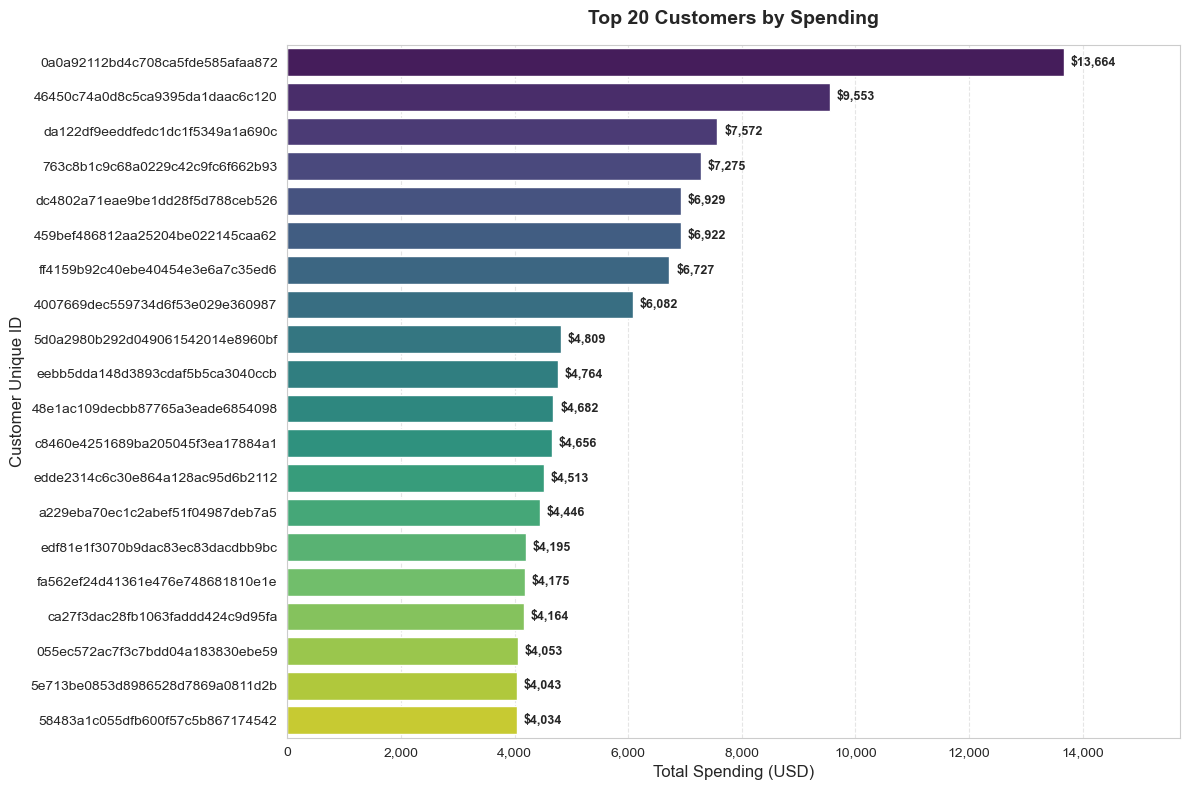

In [26]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_customers,
    x="total_spending",
    y="customer_unique_id",
    palette="viridis"
)
plt.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"${width:,.0f}", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=9)
plt.title("Top 20 Customers by Spending", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Total Spending (USD)", fontsize=12)
plt.ylabel("Customer Unique ID", fontsize=12)
plt.xlim(0, top_customers['total_spending'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../report/top_20_customers_by_spending.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
top_order_customers = (customer_df.sort_values("total_orders", ascending=False).head(20))
top_order_customers

,customer_unique_id,customer_state,total_orders,total_spending
52991,8d50f5eadf50201ccdcedfb9e2ac8455,SP,17,927.63
23476,3e43e6105506432c953e165fb2acf44c,SP,9,1172.66
76109,ca77025e7201e3b30c44b472ff346268,PE,7,1122.72
37807,6469f99c1f9dfae7733b25662e7f1782,SP,7,758.83
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,MG,7,959.01
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,PR,6,110.72
27048,47c1a3033b8b77b3ab6e109eb4d5fdf3,SP,6,944.21
90487,f0e310a6839dce9de1638e0fe5ab282a,ES,6,540.69
83573,de34b16117594161a6a89c50b289d35a,SP,6,660.94
37595,63cfc61cee11cbe306bff5857d00bfe4,RJ,6,826.32


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20632\2960253678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


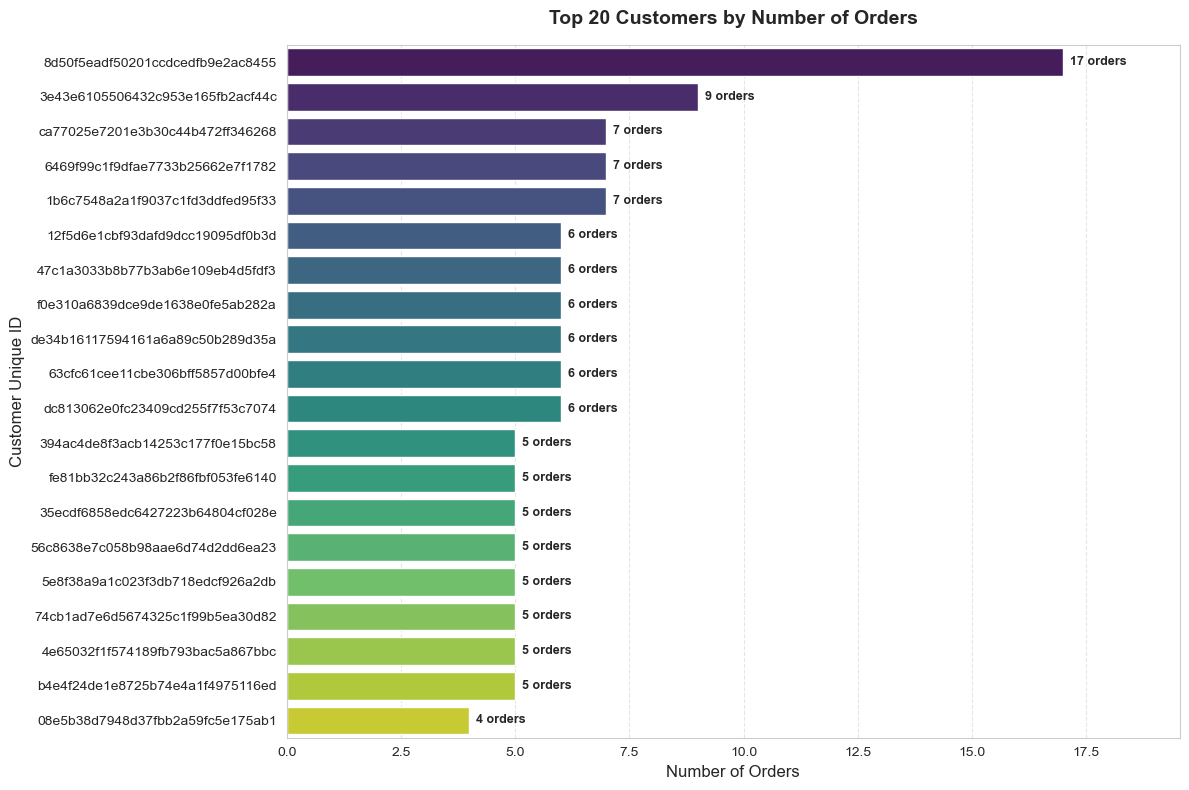

In [28]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_order_customers,
    x="total_orders",
    y="customer_unique_id",
    palette="viridis"
)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width:,.0f} orders", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=9)
plt.title("Top 20 Customers by Number of Orders", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Number of Orders", fontsize=12)
plt.ylabel("Customer Unique ID", fontsize=12)
plt.xlim(0, top_order_customers['total_orders'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../report/top_20_customers_by_orders.png', dpi=300, bbox_inches='tight')
plt.show()

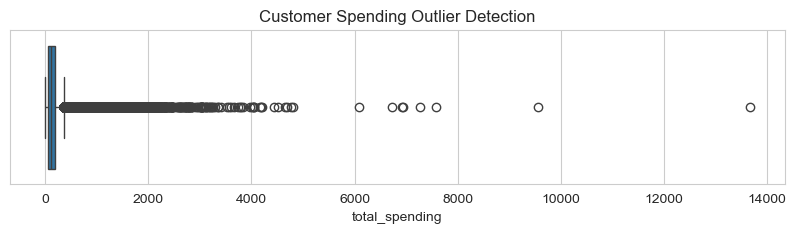

In [29]:
plt.figure(figsize=(10,2))
sns.boxplot(x=customer_df["total_spending"])
plt.title("Customer Spending Outlier Detection")
plt.savefig('../report/customer_spending_outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
Q1 = customer_df["total_spending"].quantile(0.25)
Q3 = customer_df["total_spending"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = ( Q1 - 1.5 * IQR)
upper_bound = ( Q3 + 1.5 * IQR)
spending_outliers = customer_df[( customer_df["total_spending"] < lower_bound)|( customer_df["total_spending"]  > upper_bound )]

In [31]:
print(f"Number of Outliers: {len(spending_outliers):,}")
print( f"Outlier Percentage: {len(spending_outliers)/len(customer_df)*100:.2f}%")

Number of Outliers: 7,666
Outlier Percentage: 7.97%


# Product Analysis 

In [32]:
product_df = pd.read_sql(
    "SELECT * FROM vw_product_analysis",
    engine
)

In [33]:
product_df.head()

,category_name,sales_count,revenue
0,industry_commerce_and_business,268,39669.61
1,diapers_and_hygiene,39,1567.59
2,fashion_shoes,262,23562.77
3,home_appliances,771,80171.53
4,fashion_sport,30,2119.51


In [34]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category_name  72 non-null     object 
 1   sales_count    72 non-null     int64  
 2   revenue        72 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.8+ KB


In [35]:
product_df.shape

(72, 3)

In [36]:
total_product_revenue = product_df["revenue"].sum()
print( f"Total Product Revenue: R$ {total_product_revenue:,.2f}")

Total Product Revenue: R$ 13,591,643.70


In [37]:
total_sales = product_df["sales_count"].sum()
print(f"Total Products Sold: {total_sales:,}")

Total Products Sold: 112,650


In [38]:
top_revenue_categories = (product_df.sort_values( "revenue",ascending=False ) .head(10))
top_revenue_categories

,category_name,sales_count,revenue
7,health_beauty,9670,1258681.34
48,watches_gifts,5991,1205005.68
21,bed_bath_table,11115,1036988.68
65,sports_leisure,8641,988048.97
19,computers_accessories,7827,911954.32
61,furniture_decor,8334,729762.49
50,cool_stuff,3796,635290.85
33,housewares,6964,632248.66
69,auto,4235,592720.11
27,garden_tools,4347,485256.46


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20632\1147326207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


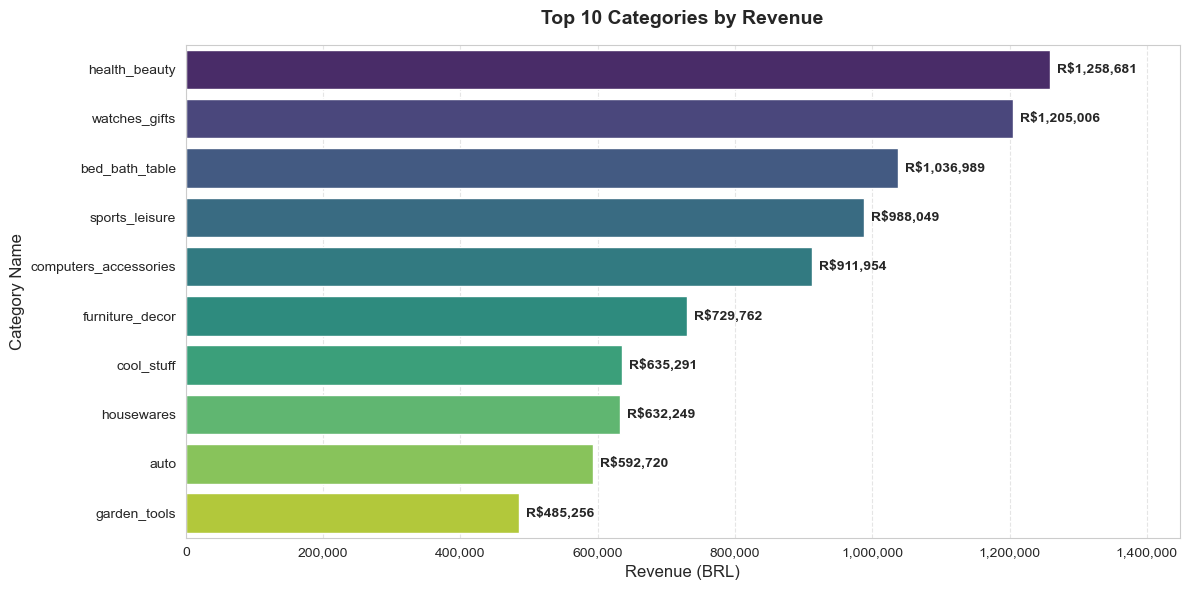

In [39]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_revenue_categories,
    x="revenue",
    y="category_name",
    palette="viridis"
)
plt.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"R${width:,.0f}", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Top 10 Categories by Revenue", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Revenue (BRL)", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xlim(0, top_revenue_categories['revenue'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../report/top_10_categories_by_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Top 10 Danh mục Sản phẩm có Doanh thu Cao nhất (Top 10 Categories by Revenue)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python trích xuất thông tin từ biến `product_df`, sắp xếp giảm dần theo cột `revenue` (`ascending=False`) và giới hạn lấy 10 bản ghi đầu tiên bằng hàm `.head(10)`.
* **Loại biểu đồ:** Biểu đồ cột ngang (Horizontal Bar chart) có hiển thị nhãn giá trị doanh thu đã làm tròn trên đầu mỗi cột.
* **Tiêu đề:** Top 10 Categories by Revenue (Top 10 danh mục sản phẩm theo doanh thu).
* **Trục hoành (X-axis):** Revenue (BRL) - Doanh thu tính theo đơn vị đồng Real Brazil (ký hiệu R$).
* **Trục tung (Y-axis):** Category Name - Tên các danh mục ngành hàng.

---

## 2. Số liệu Chi tiết của các Danh mục Ngành hàng

Dữ liệu kết hợp từ bảng số liệu Pandas và biểu đồ đường được ghi nhận chính xác như sau:

| Hạng | Danh mục Ngành hàng (Category Name) | Số lượng Bán ra (Sales Count) | Tổng Doanh thu (BRL) |
| :---: | :--- | :---: | :--- |
| **1** | health_beauty (Sức khỏe & Sắc đẹp) | 9,670 | R$ 1,258,681.34 |
| **2** | watches_gifts (Đồng hồ & Quà tặng) | 5,991 | R$ 1,205,005.68 |
| **3** | bed_bath_table (Chăn ga gối nệm) | 11,115 | R$ 1,036,988.68 |
| **4** | sports_leisure (Thể thao & Giải trí) | 8,641 | R$ 988,048.97 |
| **5** | computers_accessories (Máy tính & Phụ kiện) | 7,827 | R$ 911,954.32 |
| **6** | furniture_decor (Trang trí nội thất) | 8,334 | R$ 729,762.49 |
| **7** | cool_stuff (Hàng độc lạ / Đồ tiện ích) | 3,796 | R$ 635,290.85 |
| **8** | housewares (Đồ gia dụng) | 6,964 | R$ 632,248.66 |
| **9** | auto (Ô tô / Phụ tùng ô tô) | 4,235 | R$ 592,720.11 |
| **10** | garden_tools (Dụng cụ làm vườn) | 4,347 | R$ 485,256.46 |

---

## 3. Nhận xét và Đánh giá (Insights)

### Câu lạc bộ Doanh thu Triệu Real (Milion-BRL Club)
* Có 3 ngành hàng xuất sắc vượt mốc doanh thu 1 triệu BRL là **health_beauty**, **watches_gifts**, và **bed_bath_table**. Trong đó, `health_beauty` chiếm ngôi vương với hơn **R$ 1.25 triệu**, biến đây thành ngành hàng mũi nhọn của toàn hệ thống.

### Nghịch lý giữa Khối lượng bán (Sales Count) và Giá trị (Revenue)
Khi đối chiếu chéo giữa số đơn bán ra và số tiền thu về, chúng ta phát hiện hai trường hợp có mô hình giá trị sản phẩm (Price Point) hoàn toàn trái ngược nhau:
* **Mô hình Giá trị Cao (High-ticket items):** Danh mục `watches_gifts` chỉ bán được **5,991 sản phẩm** (thấp thứ ba trong top 10) nhưng lại đem về doanh thu đứng thứ hai toàn sàn (**R$ 1,205,006.68**). Điều này chứng tỏ giá trị trung bình của mỗi sản phẩm (Average Item Price) thuộc ngành hàng này rất cao.
* **Mô hình Khối lượng Lớn (High-volume items):** Ngược lại, danh mục `bed_bath_table` dẫn đầu tuyệt đối về số lượng bán ra với **11,115 sản phẩm**, tuy nhiên tổng doanh thu thu về lại chỉ xếp thứ ba (thấp hơn `watches_gifts`). Điều này cho thấy các sản phẩm chăn ga gối nệm có giá bán trên từng đơn vị rẻ hơn, nguồn thu phụ thuộc chính vào số lượng.

### Nhóm ngành hàng bổ trợ phía sau
* Các ngành hàng liên quan đến phong cách sống và hạ tầng như `sports_leisure` (~R$ 988k) và `computers_accessories` (~R$ 911k) đang bám đuổi rất sát nhóm dẫn đầu, hoàn toàn có tiềm năng bứt phá lên mốc triệu Real nếu có thêm các chương trình thúc đẩy tiêu dùng phù hợp.
* Danh mục `garden_tools` chốt sổ vị trí thứ 10 với doanh thu thấp nhất nhóm nhưng vẫn đạt mức ấn tượng gần nửa triệu BRL (R$ 485,256.46).

In [40]:
top_sales_categories = ( product_df.sort_values("sales_count", ascending=False).head(10))
top_sales_categories

,category_name,sales_count,revenue
21,bed_bath_table,11115,1036988.68
7,health_beauty,9670,1258681.34
65,sports_leisure,8641,988048.97
61,furniture_decor,8334,729762.49
19,computers_accessories,7827,911954.32
33,housewares,6964,632248.66
48,watches_gifts,5991,1205005.68
66,telephony,4545,323667.53
27,garden_tools,4347,485256.46
69,auto,4235,592720.11


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20632\3675691290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


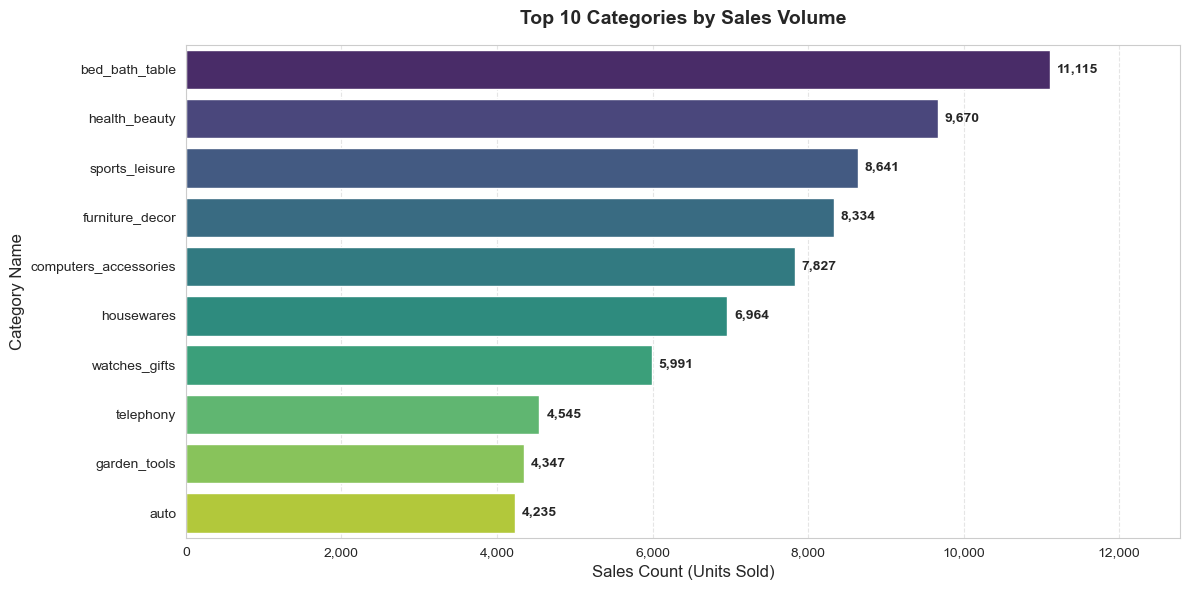

In [41]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_sales_categories,
    x="sales_count",
    y="category_name",
    palette="viridis"
)

plt.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width:,.0f}", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Top 10 Categories by Sales Volume", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Sales Count (Units Sold)", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xlim(0, top_sales_categories['sales_count'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../report/top_10_categories_by_sales_volume.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Top 10 Danh mục Sản phẩm có Khối lượng Bán ra Lớn nhất (Top 10 Categories by Sales Volume)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột ngang (Horizontal Bar chart) có hiển thị nhãn giá trị số lượng bán ra chính xác trên đầu mỗi cột.
* **Tiêu đề:** Top 10 Categories by Sales Volume (Top 10 danh mục sản phẩm theo khối lượng bán ra).
* **Trục hoành (X-axis):** Sales Count (Units Sold) - Số lượng đơn vị sản phẩm bán ra (dao động từ mốc 0 đến 12,000 đơn vị).
* **Trục tung (Y-axis):** Category Name - Tên các danh mục ngành hàng.

---

## 2. Số liệu Chi tiết của các Danh mục Ngành hàng
Biểu đồ hiển thị chính xác số lượng sản phẩm bán ra của từng danh mục theo thứ tự giảm dần như sau:
1. **bed_bath_table:** 11,115 sản phẩm
2. **health_beauty:** 9,670 sản phẩm
3. **sports_leisure:** 8,641 sản phẩm
4. **furniture_decor:** 8,334 sản phẩm
5. **computers_accessories:** 7,827 sản phẩm
6. **housewares:** 6,964 sản phẩm
7. **watches_gifts:** 5,991 sản phẩm
8. **telephony:** 4,545 sản phẩm
9. **garden_tools:** 4,347 sản phẩm
10. **auto:** 4,235 sản phẩm

---

## 3. Nhận xét và Đánh giá (Insights)

* **Sự thống trị của nhóm hàng Tiêu dùng gia đình và Chăm sóc cá nhân:**
  * Danh mục **bed_bath_table** đứng đầu danh sách một cách thuyết phục với **11,115 sản phẩm** bán ra, là ngành hàng duy nhất vượt mốc 10k đơn vị. 
  * Ngay phía sau là **health_beauty** giữ vững vị trí á quân với **9,670 sản phẩm**. Hai ngành hàng này chính là động lực cốt lõi thúc đẩy lượng giao dịch tổng thể cho toàn sàn thương mại.

* **Sự xuất hiện của nhân tố mới - "telephony":**
  * So với biểu đồ phân tích theo Doanh thu (Revenue) trước đó, danh mục **telephony** (Thiết bị/phụ kiện điện thoại) đã xuất hiện trong Top 10 về Khối lượng bán với **4,545 sản phẩm** (xếp hạng 8). 
  * Ngành hàng này đã thay thế vị trí của `cool_stuff` (vốn có doanh thu cao hơn nhưng số lượng bán ra thấp hơn). Điều này cho thấy `telephony` là nhóm sản phẩm có giá thành rẻ, dễ mua, phát sinh lượng đơn hàng lớn nhưng giá trị tích lũy trên mỗi đơn vị không quá cao.

* **Nhóm hàng Tiêu chuẩn ổn định:**
  * Các danh mục như `sports_leisure` (8,641 đơn vị), `furniture_decor` (8,334 đơn vị), và `computers_accessories` (7,827 đơn vị) tiếp tục duy trì phong độ rất ổn định khi vừa nằm trong top về khối lượng bán, vừa nằm trong top mang lại doanh thu lớn. 
  * Ngành hàng `auto` chốt sổ ở vị trí thứ 10 với **4,235 sản phẩm** được tiêu thụ thành công.

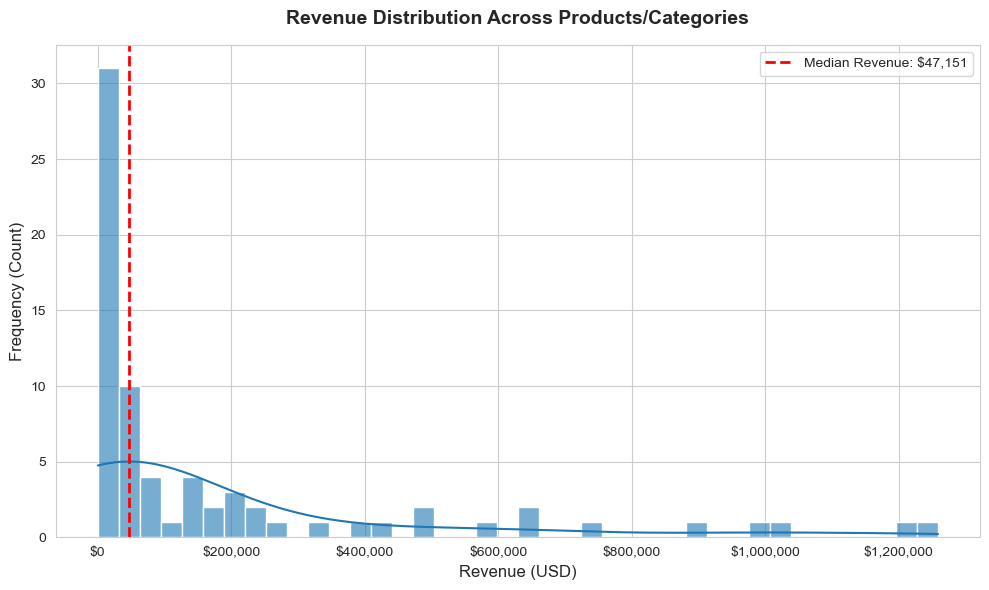

In [42]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=product_df,
    x="revenue",
    bins=40,
    kde=True,
    color="#1f77b4",  
    alpha=0.6
)
plt.ticklabel_format(style='plain', axis='both')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
median_revenue = product_df["revenue"].median()
plt.axvline(median_revenue, color='red', linestyle='--', linewidth=2, 
            label=f'Median Revenue: ${median_revenue:,.0f}')
plt.title("Revenue Distribution Across Products/Categories", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Revenue (USD)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('../report/revenue_distribution_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Phân bổ Doanh thu theo Sản phẩm/Danh mục (Revenue Distribution Across Products/Categories)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột tần suất (Histogram) kết hợp đường ước lượng mật độ nhân (KDE line) và đường thẳng đánh dấu chỉ số thống kê.
* **Tiêu đề:** Revenue Distribution Across Products/Categories (Phân bổ doanh thu giữa các Sản phẩm/Danh mục).
* **Trục hoành (X-axis):** Revenue (USD) - Doanh thu tính bằng đơn vị đô la Mỹ (dao động từ mốc $0 đến hơn $1,200,000).
* **Trục tung (Y-axis):** Frequency (Count) - Tần suất xuất hiện (Số lượng danh mục hoặc sản phẩm rơi vào khoảng doanh thu tương ứng).
* **Đường chỉ số đặc biệt:** Đường nét đứt màu đỏ thể hiện giá trị trung vị (Median Revenue) ở mức **$47,151**.

---

## 2. Các Quan sát Thống kê từ Biểu đồ

* **Cột tần suất cao nhất (Chạm đỉnh Y-axis):** Nằm ngay sát mốc **$0 đến dưới $50,000** với tần suất vượt mốc **30 lần**. Điều này chứng tỏ phần lớn các sản phẩm hoặc ngành hàng trên sàn chỉ tạo ra một lượng doanh thu nhỏ và khiêm tốn.
* **Vị trí đường Trung vị (Median):** Đường nét đứt màu đỏ cắt ở mốc **$47,151**. Định nghĩa trung vị cho thấy chính xác **50% số lượng sản phẩm/danh mục** trong hệ thống có doanh thu thấp hơn mức $47,151, và 50% còn lại có doanh thu cao hơn mức này.
* **Sự xuất hiện của các Outliers (Điểm dị biệt):** Phía bên phải trục hoành xuất hiện rải rác các cột rất thấp (tần suất chỉ 1 hoặc 2) kéo dài từ mức $400,000 lên tới tận hơn $1,200,000 (như danh mục `health_beauty` hay `watches_gifts` đạt mốc triệu đô ở biểu đồ trước).

---

## 3. Nhận xét và Đánh giá Hình dạng Phân phối (Insights)

* **Phân phối lệch phải nghiêm trọng (Right-Skewed / Positively Skewed Distribution):**
  * Đồ thị có hình dáng lệch phải rất rõ ràng với phần "đuôi" kéo dài sang bên phải. 
  * Đây là mô hình phân phối cực kỳ điển hình trong kinh doanh thương mại điện tử, phản ánh quy luật Pareto (Quy luật 80/20). Hệ thống có một số lượng khổng lồ các sản phẩm/ngành hàng mang lại doanh thu thấp (phần đầu đồ thị), nhưng tổng doanh thu lại bị chi phối và kéo mạnh về phía bên phải bởi một số ít các sản phẩm "vua" có doanh thu đột biến lên tới hàng triệu USD (phần đuôi đồ thị).
  * Do hình dáng lệch phải này, nếu tính chỉ số doanh thu trung bình (Mean), giá trị thu được chắc chắn sẽ bị kéo lên cao hơn rất nhiều so với con số trung vị $47,151 hiện tại.

In [43]:
pareto_df = (product_df.sort_values( "revenue",ascending=False).reset_index(drop=True))
pareto_df["revenue_pct"] = ( pareto_df["revenue"]/ pareto_df["revenue"].sum()) * 100
pareto_df["cumulative_pct"] = (pareto_df["revenue_pct"].cumsum())

In [44]:
pareto_df.head()

,category_name,sales_count,revenue,revenue_pct,cumulative_pct
0,health_beauty,9670,1258681.34,9.260700,9.260700
1,watches_gifts,5991,1205005.68,8.865783,18.126483
2,bed_bath_table,11115,1036988.68,7.629605,25.756088
3,sports_leisure,8641,988048.97,7.269533,33.025621
4,computers_accessories,7827,911954.32,6.709669,39.735290


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20632\4186012717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20632\4186012717.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='right')


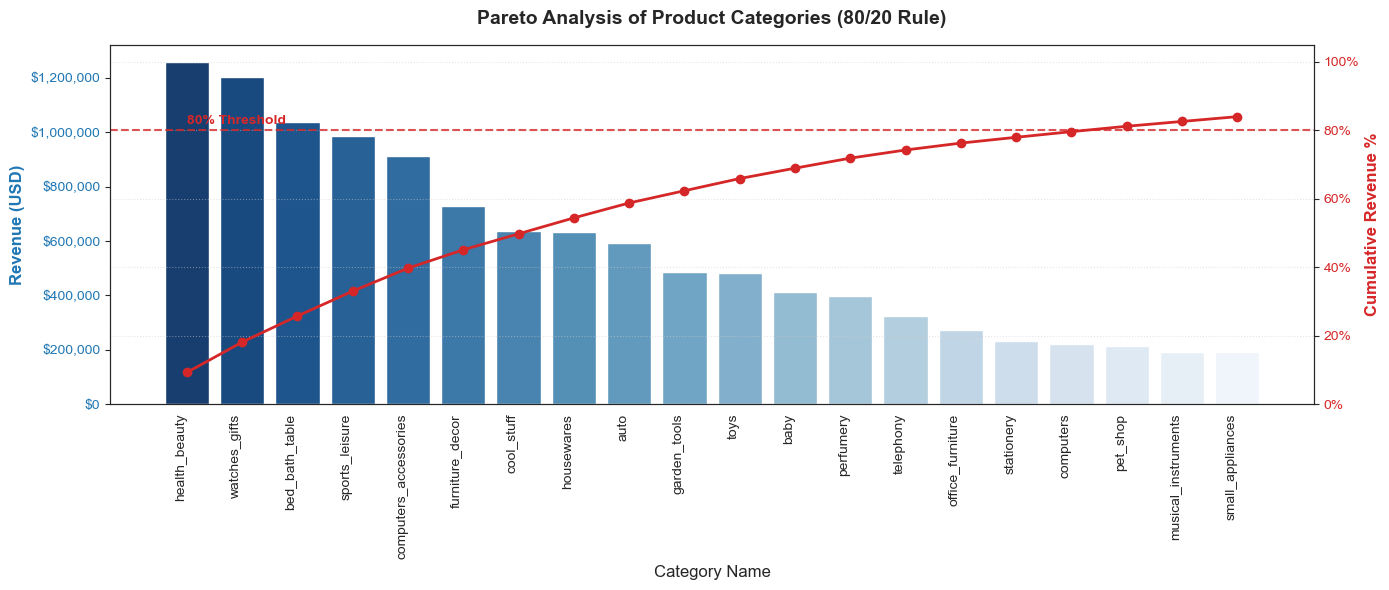

In [45]:
sns.set_style("white") 
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=pareto_df.head(20),
    x="category_name",
    y="revenue",
    ax=ax1,
    palette="Blues_r"
)

ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax1.set_ylabel("Revenue (USD)", fontsize=12, fontweight='bold', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='right')
ax1.set_xlabel("Category Name", fontsize=12)
ax2 = ax1.twinx()
ax2.plot(
    pareto_df.head(20)["category_name"],
    pareto_df.head(20)["cumulative_pct"],
    color="#d62728",
    marker="o",
    linewidth=2,
    label="Cumulative %"
)

ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:.0f}%"))
ax2.set_ylim(0, 105)
ax2.set_ylabel("Cumulative Revenue %", fontsize=12, fontweight='bold', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.axhline(80, color="#d62728", linestyle="--", linewidth=1.5, alpha=0.8)
ax2.text(0, 82, "80% Threshold", color="#d62728", fontsize=10, fontweight='bold')
plt.title("Pareto Analysis of Product Categories (80/20 Rule)", fontsize=14, pad=15, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.5)  

plt.tight_layout()
plt.savefig('../report/pareto_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Pareto cho Danh mục Sản phẩm (Pareto Analysis - 80/20 Rule)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Biến `pareto_df` được tạo ra bằng cách tính tỷ trọng doanh thu từng ngành hàng (`revenue_pct`) và cộng dồn tuyến tính (`cumulative_pct` dùng hàm `.cumsum()`) sau khi đã sắp xếp giảm dần theo doanh thu.
* **Loại biểu đồ:** Biểu đồ trục kép (Dual-axis chart) kết hợp giữa biểu đồ cột (Bar chart - thể hiện doanh thu gốc) và biểu đồ đường (Line chart - thể hiện tỷ lệ phần trăm cộng dồn).
* **Tiêu đề:** Pareto Analysis of Product Categories (80/20 Rule).
* **Trục tung bên trái (Left Y-axis):** Revenue (USD) - Doanh thu gốc (Màu xanh dương).
* **Trục tung bên phải (Right Y-axis):** Cumulative Revenue % - Tỷ lệ phần trăm doanh thu cộng dồn (Màu đỏ, từ 0% đến 100%).
* **Đường ngưỡng đặc biệt:** Đường nét đứt màu đỏ nằm ngang ở mốc **80% Threshold** để xác định ranh giới Pareto.

---

## 2. Số liệu Chi tiết từ Mã nguồn (Top 5 Danh mục Sản phẩm)

Dữ liệu trích xuất chính xác từ hàm `.head()` của mã nguồn cho thấy giá trị doanh thu và tỷ lệ cộng dồn của nhóm dẫn đầu:

| Hạng | Danh mục Ngành hàng (Category Name) | Doanh thu (USD) | Tỷ trọng đơn lẻ (`revenue_pct`) | Tỷ lệ cộng dồn (`cumulative_pct`) |
| :---: | :--- | :--- | :---: | :---: |
| **1** | health_beauty | 1,258,681.34 | ~ 9.26% | 9.26% |
| **2** | watches_gifts | 1,205,005.68 | ~ 8.87% | 18.13% |
| **3** | bed_bath_table | 1,036,988.68 | ~ 7.63% | 25.76% |
| **4** | sports_leisure | 988,048.97 | ~ 7.27% | 33.03% |
| **5** | computers_accessories | 911,954.32 | ~ 6.71% | **39.74%** |

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Xác định nhóm sản phẩm "Key" chi phối doanh thu (Nhóm A)
* Chỉ cần nhìn vào 5 danh mục đầu tiên (từ `health_beauty` đến `computers_accessories`), nhóm này đã đóng góp tới **39.74%** (gần 40%) tổng doanh thu của toàn bộ doanh nghiệp.
* Dựa vào đường biểu diễn màu đỏ cắt qua đường nét đứt **80% Threshold**, chúng ta có thể đếm được chính xác số lượng ngành hàng cốt lõi. Ranh giới này chạm tới vị trí của danh mục **stationery** hoặc **computers**.
* **Đánh giá quy luật 80/20:** Biểu đồ chứng minh một thực tế rằng khoảng **15 - 17 danh mục đầu tiên** (trên tổng số rất nhiều ngành hàng hiển thị ở đuôi đồ thị) đã gánh vác và tạo ra **80% tổng doanh thu** cho doanh nghiệp. 

### Hiệu ứng phân cấp màu sắc trực quan (Color Gradient)
* Biểu đồ sử dụng dải màu đổ từ xanh dương đậm sang xanh nhạt dần và cuối cùng là trắng xám rất thông minh. 
* Các cột màu xanh đậm (từ `health_beauty` đến `computers_accessories`) đại diện cho những thực thể cần được ưu tiên tối đa trong các quyết định kinh doanh. 
* Các danh mục ở nửa phía bên phải (từ `office_furniture` đến `small_appliances`) có cột doanh thu rất thấp và đường cong tích lũy lúc này đã đi ngang (bão hòa), đóng góp cực kỳ ít vào sự tăng trưởng tài chính.

---

## 4. Đề xuất Hành động dựa trên Phân tích Pareto

1. **Tập trung nguồn lực (Focus Strategy):**
   * Doanh nghiệp cần dồn 80% nguồn lực (ngân sách marketing, nhân sự tối ưu, chiến dịch khuyến mãi) vào nhóm các ngành hàng nằm phía trước ngưỡng 80% (đặc biệt là Top 5: Sức khỏe, Đồng hồ, Chăn ga, Thể thao, Máy tính). Bất kỳ sự sụt giảm nào ở nhóm này cũng sẽ trực tiếp làm lung lay doanh thu toàn công ty.

2. **Quản lý kho bãi và Chuỗi cung ứng (Inventory Control):**
   * Áp dụng phương pháp phân loại ABC trong quản trị kho. Nhóm sản phẩm trước ngưỡng 80% phải luôn được đảm bảo lượng tồn kho an toàn (Safety stock) để tránh tình trạng đứt gãy hàng hóa (Stockout).

3. **Tinh gọn danh mục hàng hóa (Long-tail Optimization):**
   * Đối với các ngành hàng nằm ở phần đuôi bão hòa (như `musical_instruments`, `small_appliances`), doanh nghiệp không nên đổ thêm chi phí quảng cáo đại trà mà có thể cân nhắc giảm bớt số lượng mẫu mã để tối ưu chi phí lưu kho.

In [46]:
categories_80 = (pareto_df[pareto_df["cumulative_pct"] <= 80])
print(f"{len(categories_80)} categories generate 80% of total revenue")

17 categories generate 80% of total revenue


In [47]:
treemap_df = (product_df.sort_values("revenue", ascending=False ).head(15))

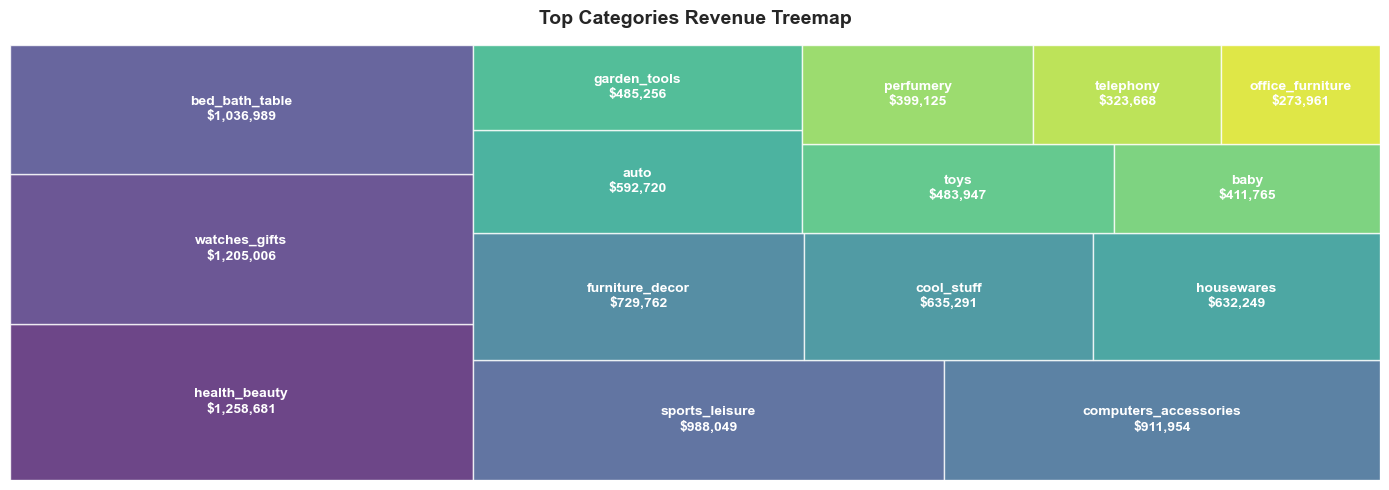

In [48]:
plt.figure(figsize=(14, 5))
labels = [f"{row['category_name']}\n${row['revenue']:,.0f}" for _, row in treemap_df.iterrows()]
colors = sns.color_palette("viridis", len(treemap_df))
squarify.plot(
    sizes=treemap_df["revenue"],
    label=labels,
    color=colors,
    alpha=0.8,
    text_kwargs={'fontsize': 10, 'weight': 'bold', 'color': 'white'}
)
plt.axis("off")
plt.title("Top Categories Revenue Treemap", fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/top_categories_revenue_treemap.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Sơ đồ Cây Doanh thu theo Danh mục (Top Categories Revenue Treemap)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Biến `treemap_df` trích xuất từ `product_df`, sắp xếp giảm dần theo doanh thu (`revenue`) và lấy 15 bản ghi đứng đầu bằng hàm `.head(15)`.
* **Loại biểu đồ:** Sơ đồ cây (Treemap) sử dụng thư viện `squarify` trong Python. Kích thước của mỗi khối hình chữ nhật đại diện cho quy mô doanh thu của danh mục đó.
* **Tiêu đề:** Top Categories Revenue Treemap (Sơ đồ cây doanh thu của các danh mục hàng đầu).
* **Bảng màu:** Sử dụng palette màu `viridis` của Seaborn, phân bậc màu sắc dịch chuyển từ sắc tím/xanh dương đậm (doanh thu cao nhất) sang sắc xanh lá/vàng (doanh thu thấp hơn).

---

## 2. Số liệu Chi tiết từ Biểu đồ
Biểu đồ hiển thị chính xác giá trị doanh thu của 15 danh mục ngành hàng dẫn đầu (đã được làm tròn thành số nguyên):

1. **health_beauty:** $1,258,681
2. **watches_gifts:** $1,205,006
3. **bed_bath_table:** $1,036,989
4. **sports_leisure:** $988,049
5. **computers_accessories:** $911,954
6. **furniture_decor:** $729,762
7. **cool_stuff:** $635,291
8. **housewares:** $632,249
9. **auto:** $592,720
10. **garden_tools:** $485,256
11. **toys:** $483,947
12. **baby:** $411,765
13. **perfumery:** $399,125
14. **telephony:** $323,668
15. **office_furniture:** $273,961

---

## 3. Nhận xét và Đánh giá (Insights)

### Trực quan hóa cấu trúc tỷ trọng rõ ràng
* Treemap hoàn thành xuất sắc vai trò thể hiện phân cấp thị trường. Ba khối lớn nhất nằm ở góc bên trái (`health_beauty`, `watches_gifts`, và `bed_bath_table`) chiếm diện tích gần 1/3 toàn bộ biểu đồ. Đây là hình ảnh trực quan hóa rất sinh động cho nhóm dẫn đầu của phân tích Pareto trước đó.

### Sự dịch chuyển dòng doanh thu ở nhóm giữa
* Nhóm có doanh thu cận triệu đô bao gồm `sports_leisure` ($988,049) và `computers_accessories` ($911,954) chiếm hai khối dài hình chữ nhật ở cạnh đáy biểu đồ, định hình nhóm đóng góp quan trọng thứ hai cho doanh nghiệp.
* Biểu đồ mở rộng góc nhìn xuống các vị trí từ 11 đến 15 (vốn bị khuất ở các phân tích rút gọn trước): `toys`, `baby`, `perfumery`, `telephony`, và `office_furniture`. Doanh thu của các ngành hàng này nhỏ dần, thể hiện qua các ô vuông có kích thước thu hẹp và chuyển hẳn sang tông màu xanh lá sáng/vàng.

---


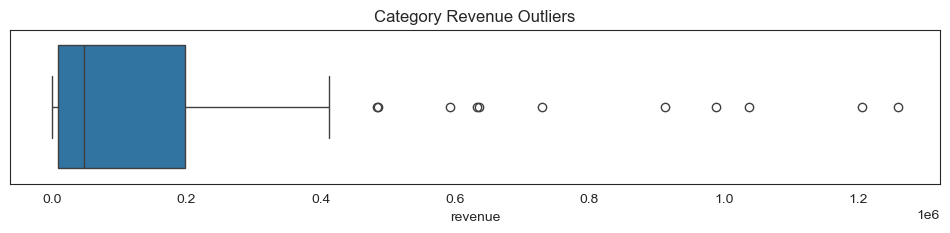

In [49]:
plt.figure(figsize=(12,2))
sns.boxplot(   x=product_df["revenue"])
plt.title("Category Revenue Outliers")
plt.savefig('../report/category_revenue_outliers.png', dpi=300, bbox_inches='tight')
plt.show()